<a href="https://www.kaggle.com/code/kamalkumarg25ait2028/g25ait2028-mlops-a2-classifying-goodreads?scriptVersionId=320932267" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Training and Fine-Tuning RoBERTa for Classification
## Classifying Goodreads Reviews By Book Genre

**Author:** Chaurasia Kamalkumar Lallanprasad | **Roll Number:** G25AIT2028  
**Program:** PGD Artificial Intelligence — IIT Jodhpur  
**Assignment:** MLOps Assignment 2

---

*Original notebook by Maria Antoniak, Melanie Walsh, and the [AI for Humanists](https://aiforhumanists.com/) Team*  
Updated: 2024-11-05

This notebook will demonstrate how users can train and fine-tune a RoBERTa model for classification with the popular HuggingFace `transformers` Python library.

We will fine-tune a RoBERTa model on Goodreads reviews from the [UCSD Book Graph](https://mengtingwan.github.io/data/goodreads.html) with the goal of predicting the genre of the book being reviewed. The genres include:
- children
- comics & graphic
- fantasy & paranormal
- history & biography
- mystery, thriller, & crime
- poetry
- romance
- young adult

**Basic steps involved in using RoBERTa and HuggingFace:**
1. Divide your data into training and test sets.
2. Encode your data into a format RoBERTa will understand.
3. Combine your data and labels into dataset objects.
4. Load the pre-trained RoBERTa model.
5. Fine-tune the model using your training data.
6. Predict new labels and evaluate performance on your test data.


## Task 1: Notebook Setup — Download & Import into Kaggle

## Import necessary Python libraries and modules


First, we will import necessary Python libraries and modules. These include as `gdown`, for downloading large files from Google Drive (where we will get our UCSD Goodreads reviews), as well as scikit-learn (`sklearn`) and PyTorch (`torch`), for various machine learning tools.

In [1]:
# !pip3 install -q -U transformers>=4.40.0 torch>=2.2.0 accelerate>=1.1.0 sentencepiece nbformat wandb gdown scikit-learn pandas numpy requests matplotlib seaborn ipywidgets huggingface_hub certifi python-dotenv

import os, certifi
# os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()
# os.environ["SSL_CERT_FILE"] = certifi.where()

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()

os.environ["WANDB_API_KEY"] = user_secrets.get_secret("WANDB_API_KEY")
os.environ["HF_TOKEN"] = user_secrets.get_secret("HF_TOKEN")

# Remove any stale wandb IPython hooks left over from a previous session.
_ip = get_ipython()
if _ip is not None:
    for _event in ('pre_run_cell', 'post_run_cell'):
        _stale = [
            cb for cb in list(_ip.events.callbacks.get(_event, []))
            if 'wandb' in str(type(getattr(cb, '__self__', cb))).lower()
        ]
        for cb in _stale:
            try:
                _ip.events.unregister(_event, cb)
            except Exception:
                pass

try:
    import wandb
    wandb.teardown()
except Exception:
    pass


In [2]:
# Basic Python modules
from collections import defaultdict
import random
import pickle

# For downloading large files from Google Drive
# https://github.com/wkentaro/gdown
import gdown

# For working with gzip files
# https://docs.python.org/3/library/gzip.html
import gzip

# For working with JSON files
import json

# For data manipulation and analysis
import pandas as pd
import numpy as np

# For machine learning tools and evaluation
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# For deep learning
# https://pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html
import torch

# For plotting and data visualization
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import ticker
sns.set(style='ticks', font_scale=1.2)

from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
 

The HuggingFace [`transformers` Python library](https://huggingface.co/transformers/installation.html) is included in Colab by default now, so we do not need to install it (but this is how you would install it with `pip`).

From `transformers`, we will import modules for `RoBERTa`, a **R**obustly **O**ptimized **BERT** **P**re-training **A**pproach developed by Facebook AI Research. RoBERTa improves upon the original BERT by removing the Next Sentence Prediction (NSP) objective (shown to be sub-optimal), training with **dynamic masking** (a fresh random mask per epoch rather than a fixed one at preprocessing time), using much larger mini-batches, and training on significantly more data for longer. The `roberta-base` variant comes with 12 transformer layers, a hidden size of 768, 12 attention heads, ~125M parameters, and a **byte-level BPE** vocabulary of 50,000 tokens — trained on 160GB of diverse English text.


In [3]:
from transformers import DebertaV2ForSequenceClassification, DebertaV2Tokenizer
from transformers import Trainer, TrainingArguments


In [4]:
from transformers import RobertaForSequenceClassification , RobertaTokenizer

## Set parameters and file paths


In [5]:
# HF_MODEL_CLASS = DebertaV2ForSequenceClassification
# HF_TOKENIZER_CLASS = DebertaV2Tokenizer
# model_name = 'microsoft/deberta-v3-small'

HF_MODEL_CLASS = RobertaForSequenceClassification
HF_TOKENIZER_CLASS = RobertaTokenizer
model_name = 'roberta-base'

# Device: 'mps' for Apple Silicon, 'cuda' for NVIDIA GPU, 'cpu' as fallback
device_name = 'cuda'

# Maximum number of tokens per input sequence
max_length = 512

# Directory to save the fine-tuned model
cached_model_directory_name = 'goodreads-reviews-genres'

# Dataset parameters
DATA_SET_HEAD = 10000    # max reviews to read per genre
DATA_SET_SAMPLE = 2000   # reviews to randomly sample per genre


## Load and sample Goodreads data


In this cell, we create a Python dictionary with each genre and the link to the corresponding UCSD Goodreads review data for that genre.

*If you manually click on any of the URLs, you will be able to download the data for that genre. For example, here's the link for poetry: https://datarepo.eng.ucsd.edu/mcauley_group/gdrive/goodreads/byGenre/goodreads_reviews_poetry.json.gz*

In [6]:
# This is where our target data is hosted on the web. You only need these paths for the book review dataset.

# Source: https://mengtingwan.github.io/data/goodreads.html#datasets

genre_url_dict = {'poetry':                 'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_poetry.json.gz',
                  'children':               'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_children.json.gz',
                  'comics_graphic':         'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_comics_graphic.json.gz',
                  'fantasy_paranormal':     'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_fantasy_paranormal.json.gz',
                  'history_biography':      'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_history_biography.json.gz',
                  'mystery_thriller_crime': 'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_mystery_thriller_crime.json.gz',
                  'romance':                'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_romance.json.gz',
                  'young_adult':            'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_young_adult.json.gz'}

Next we loop through this dictionary and stream each gzipped review file directly from the UCSD server, loading up to 10,000 reviews per genre and randomly sampling 2,000 from them.


In [7]:
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

def load_reviews(url, head=10000, sample_size=2000):
    """Stream reviews from a gzipped JSON-lines URL and return a random sample.

    Retries up to 3 times on transient network errors with exponential back-off,
    and raises immediately on non-2xx HTTP responses.
    """
    session = requests.Session()
    retries = Retry(
        total=3,
        backoff_factor=2,               # waits 2 s, 4 s, 8 s between retries
        status_forcelist=[500, 502, 503, 504],
        allowed_methods=['GET'],
    )
    session.mount('https://', HTTPAdapter(max_retries=retries))
    session.mount('http://',  HTTPAdapter(max_retries=retries))

    response = session.get(url, stream=True, timeout=120)
    response.raise_for_status()         # raises on 4xx / 5xx responses
    response.raw.decode_content = True  # required for gzip to work over streaming
    print(f'  HTTP {response.status_code} — {url.split("/")[-1]}')

    reviews = []
    count = 0
    with gzip.open(response.raw, 'rt', encoding='utf-8') as file:
        for line in file:
            text = json.loads(line).get('review_text', '').strip()
            if not text:            # skip empty / missing reviews
                continue
            reviews.append(text)
            count += 1
            if head is not None and count >= head:  # stop after `head` reviews
                break

    return random.sample(reviews, min(sample_size, len(reviews)))

# Reviews by genre
genre_reviews_dict = {}

# Load reviews for each genre
for genre, url in genre_url_dict.items():
    print(f'Loading reviews for genre: {genre}')
    genre_reviews_dict[genre] = load_reviews(url, head=DATA_SET_HEAD, sample_size=DATA_SET_SAMPLE)


Loading reviews for genre: poetry
  HTTP 200 — goodreads_reviews_poetry.json.gz
Loading reviews for genre: children
  HTTP 200 — goodreads_reviews_children.json.gz
Loading reviews for genre: comics_graphic
  HTTP 200 — goodreads_reviews_comics_graphic.json.gz
Loading reviews for genre: fantasy_paranormal
  HTTP 200 — goodreads_reviews_fantasy_paranormal.json.gz
Loading reviews for genre: history_biography
  HTTP 200 — goodreads_reviews_history_biography.json.gz
Loading reviews for genre: mystery_thriller_crime
  HTTP 200 — goodreads_reviews_mystery_thriller_crime.json.gz
Loading reviews for genre: romance
  HTTP 200 — goodreads_reviews_romance.json.gz
Loading reviews for genre: young_adult
  HTTP 200 — goodreads_reviews_young_adult.json.gz


Let's preview a couple of the key-value pairs in `genre_reviews_dict`

In [8]:
for _genre, _reviews in genre_reviews_dict.items():
   print(_genre)
   print(random.sample(_reviews, 1)[0])

poetry
I could read this book 100 times and never grasp all the meaning. Gibraan is a poet and philosopher. You'll be touched and you'll grow in wisdom. Can't give it enough stars.
children
I actually liked this outing a lot better than the Belly Button book, which is the previous Boynton book I read to my daughter. In some spots it made me laugh.
comics_graphic
Any space opera book you'd think would be inherently good ... especially if it has the Starjammers and the Shi'ar, both of which I've loved since I was a kid. Not only that, Christopher Yost isn't that bad of a writer, but this ... this was an exercise in boredom. Havok's over dramatic soliloquies, coupled with his self doubt got really old after a while, and Vulcan is one of dumbest characters to come a long in a while. You think since he's of the Summers lineage he'd have more grit ... but he's kind of a big old baby.
fantasy_paranormal
I wasn't sure about this book when I started, it seemed to start a bit slower than the fir

Here we use `pickle` to save this Python dictionary to a `.pickle` file so we can easily load it later.

*The `pickle` module allows you to save and load Python objects like lists and dictionaries.*

In [9]:
pickle.dump(genre_reviews_dict, open('genre_reviews_dict.pickle', 'wb'))
# genre_reviews_dict = pickle.load(open('genre_reviews_dict.pickle', 'rb'))

## Split the data into training and test sets


When training a machine learning model, it is necessary to split your training data into two parts: a "training" set and a "test" set.

We will train our RoBERTa model on the "training" set of Goodreads reviews and then we will evaluate how well it is performing by running it on the "test" set of Goodreads reviews that the model has never seen before.

Normally, to tune the hyperparameters, you should also create a "validation" set for tuning, and only use the "test" set once, at the end of all tuning. For simplicity, in this tutorial, we will only using a training and test set.


In [10]:
train_texts = []
train_labels = []

test_texts = []
test_labels = []

for _genre, _reviews in genre_reviews_dict.items():

  _reviews = random.sample(_reviews, 1000) # Use a very small set as an example.

  for _review in _reviews[:800]:
    train_texts.append(_review)
    train_labels.append(_genre)
  for _review in _reviews[800:]:
    test_texts.append(_review)
    test_labels.append(_genre)

Show how many Goodreads reviews and labels we have in each category: 6400 training reviews, 6400 training labels (genres), 1600 test reviews, 1600 test labels (genre)

In [11]:
len(train_texts), len(train_labels), len(test_texts), len(test_labels)

(6400, 6400, 1600, 1600)

Here's an example of a training label and review:

In [12]:
train_labels[0], train_texts[0]

('poetry',
 'Planned for my October 2009 book club (we ended up skipping September and moving everything back a month, due to other commitments). I loved this when I read it in college, so am curious what my reaction now will be.')

## Run a baseline model (logistic regression)

Here we train and evaluate a simple TF-IDF baseline model using logistic regression.

We find better-than-random performance, even for a very small dataset. We'll see whether RoBERTa can beat this good baseline!


In [13]:
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(train_texts)
X_test = vectorizer.transform(test_texts)

We train a logistic regression model from scikit-learn on the Goodreads training data, and then we use the trained model to make predictions on our Goodreads review test set.

In [14]:
model = LogisticRegression(max_iter=1000).fit(X_train, train_labels)
predictions = model.predict(X_test)

We can use scikit-learn's `classification_report` function to evaluate how well the logistic regression model's predictions match up with the true labels for the Goodreads reviews.

Importantly, we can see that our average scores are above random performance (we have 8 classes, so random performance would be ~0.2).

In [15]:
print(classification_report(test_labels, predictions))

                        precision    recall  f1-score   support

              children       0.67      0.63      0.65       200
        comics_graphic       0.77      0.67      0.71       200
    fantasy_paranormal       0.33      0.28      0.30       200
     history_biography       0.53      0.51      0.52       200
mystery_thriller_crime       0.53      0.48      0.51       200
                poetry       0.58      0.74      0.65       200
               romance       0.57      0.62      0.59       200
           young_adult       0.32      0.35      0.34       200

              accuracy                           0.54      1600
             macro avg       0.54      0.54      0.53      1600
          weighted avg       0.54      0.54      0.53      1600



## Encode data for RoBERTa

We're going to transform our texts and labels into a format that RoBERTa (via HuggingFace and PyTorch) will understand. This is called *encoding* the data.

Here are the steps we need to follow:

1. The labels — in this case, Goodreads genres — need to be turned into integers rather than strings.

2. The texts — in this case, Goodreads reviews — need to be truncated if they're more than 512 tokens or padded if they're fewer than 512 tokens.

3. We need to add special tokens to help RoBERTa:

| Special token | Explanation |
|---|---|
| `<s>` | Start token of every document (CLS equivalent) |
| `</s>` | End/separator token (SEP equivalent) |
| `<pad>` | Padding up to 512 tokens |
| `Ġ` | Byte-level BPE word-start prefix |


## Task 2: Load Pre-trained Model from Hugging Face

### Model Selection Rationale

For this genre classification task, `FacebookAI/roberta-base` was selected over the baseline candidate `distilbert-base-cased` based on pre-training robustness, tokenizer design, and cross-platform numerical stability.

`distilbert-base-cased` is a distilled version of BERT that is 40% smaller and 60% faster. However, distillation compresses representational capacity, and BERT's original pre-training includes a **Next Sentence Prediction (NSP)** objective that has since been shown to be sub-optimal — it can actually *hurt* performance on single-sentence classification tasks by introducing noise into the learned representations.

`FacebookAI/roberta-base` removes NSP entirely and trains with **dynamic masking** (a fresh random mask per epoch rather than one fixed at preprocessing time), significantly larger mini-batches (8K vs BERT's 256), and 10× more training data. These changes make RoBERTa a more robustly trained BERT — achieving higher GLUE benchmark scores without any architectural change. At ~125M parameters it is production-proven, numerically stable on both MPS and CUDA, and fully compatible with the standard HuggingFace `Trainer` workflow.

| Dimension | `distilbert-base-cased` | `FacebookAI/roberta-base` ✅ |
|-----------|------------------------|------------------------------|
| Attention mechanism | Standard self-attention | Standard self-attention |
| Pre-training objective | Masked LM + NSP (static mask) | Masked LM only, dynamic masking, no NSP |
| Tokenizer | WordPiece (`##` suffix) | Byte-level BPE (`Ġ` prefix, 50K vocab) |
| Parameters | ~66M | ~125M |
| GLUE avg. score | ~77 | ~88 |


### Step 1 — Load the Tokenizer from Hugging Face Hub

We load `RobertaTokenizer` directly from the Hugging Face Hub using `from_pretrained(model_name)`. Unlike BERT's WordPiece tokenizer (which appends `##` to subword continuations), RoBERTa uses a **byte-level BPE** tokenizer where word-start tokens are prefixed with `Ġ`. The tokenizer truncates review text to 512 tokens and adds the special tokens `<s>` (start), `</s>` (end/separator), and `<pad>` (padding).


In [16]:
tokenizer = HF_TOKENIZER_CLASS.from_pretrained(model_name) # The model_name needs to match our pre-trained model.

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Here we will create a map of our labels, or Goodreads genres, to integer keys. We take the unique labels, and then we make a dictionary that associates each label/tag with an integer.

**Note:** HuggingFace documentation sometimes refers to "labels" as "tags" but these are the same thing. We use "labels" throughout this notebook for clarity.

In [17]:
unique_labels = sorted(set(train_labels))
label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label = {idx: label for label, idx in label2id.items()}

In [18]:
label2id.keys()

dict_keys(['children', 'comics_graphic', 'fantasy_paranormal', 'history_biography', 'mystery_thriller_crime', 'poetry', 'romance', 'young_adult'])

In [19]:
id2label.keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7])

Now let's encode our texts and labels!

In [20]:
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=max_length)
test_encodings  = tokenizer(test_texts, truncation=True, padding=True, max_length=max_length)

train_labels_encoded = [label2id[y] for y in train_labels]
test_labels_encoded  = [label2id[y] for y in test_labels]

**Examine a Goodreads review in the training set after encoding**

In [21]:
' '.join(train_encodings[0].tokens[0:100])

'<s> Pl anned Ġfor Ġmy ĠOctober Ġ2009 Ġbook Ġclub Ġ( we Ġended Ġup Ġskipping ĠSeptember Ġand Ġmoving Ġeverything Ġback Ġa Ġmonth , Ġdue Ġto Ġother Ġcommitments ). ĠI Ġloved Ġthis Ġwhen ĠI Ġread Ġit Ġin Ġcollege , Ġso Ġam Ġcurious Ġwhat Ġmy Ġreaction Ġnow Ġwill Ġbe . </s> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad>'

**Examine a Goodreads review in the test set after encoding**

In [22]:
' '.join(test_encodings[0].tokens[0:100])

"<s> l Ġsh k Ġ' n Ġsh kh Sy @ Ġl H l j Ġm n Ġ' k th r Ġl sh kh Sy t Ġthr @ Ġll sh k wk Ġ, Ġw Ġl ` w T f ! Ġ Ċ Ġb ` yd an Ġ` n Ġk l Ġm Ġyr wy Ġ` n Ġl H l j Ġ, Ġw b ` yd an Ġ` n Ġk l Ġm Ġy sh ` Ġ` n h Ġb kh Sw S Ġw f th Ġm n Ġth m h Ġbl z nd q @ Ġ' w Ġdf ` Ġlb ` D Ġ`"

**Examine the training labels after encoding**

In [23]:
set(train_labels_encoded)

{0, 1, 2, 3, 4, 5, 6, 7}

**Examine the test labels after encoding**

In [24]:
set(test_labels_encoded)

{0, 1, 2, 3, 4, 5, 6, 7}

## Make a custom Torch dataset


Here we combine the encoded labels and texts into dataset objects. We use the custom Torch `MyDataSet` class to make a `train_dataset` object from  the `train_encodings` and `train_labels_encoded`. We also make a `test_dataset` object from `test_encodings`, and `test_labels_encoded`.

In [25]:
class MyDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [26]:
train_dataset = MyDataset(train_encodings, train_labels_encoded)
test_dataset = MyDataset(test_encodings, test_labels_encoded)

**Examine a Goodreads review in the Torch `training_dataset` after encoding**

In [27]:
' '.join(train_dataset.encodings[0].tokens[0:100])

'<s> Pl anned Ġfor Ġmy ĠOctober Ġ2009 Ġbook Ġclub Ġ( we Ġended Ġup Ġskipping ĠSeptember Ġand Ġmoving Ġeverything Ġback Ġa Ġmonth , Ġdue Ġto Ġother Ġcommitments ). ĠI Ġloved Ġthis Ġwhen ĠI Ġread Ġit Ġin Ġcollege , Ġso Ġam Ġcurious Ġwhat Ġmy Ġreaction Ġnow Ġwill Ġbe . </s> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad>'

**Examine a Goodreads review in the Torch `test_dataset` after encoding**

In [28]:
' '.join(test_dataset.encodings[1].tokens[0:100])

"<s> ' j ml hm Ġt lt Ġk hr fn Ġw j H Ġm ` Ġn Ġj H Ġm w Ġm w j wd @ Ġb hd Ġl dy wn Ġ Ċ Ġ' n Ġk l Ġm Ġt dh kr Ġt Hy @ Ġl ` l m Ġy sr H Ġk hy ly Ġ Ċ Ġkn ĠSw ty Ġl sh Ġ` y ly Ġ.. Ġb s Ġ` ly Ġ Ċ Ġk nt ĠH s W Ġn y Ġb hz W Ġl md rs @ Ġ Ċ Ġkn Ġl ` l m Ġm n Ġfr H th Ġyr q S Ġ`"

## Load pre-trained RoBERTa model


### Step 2 — Load the Pre-trained Model from Hugging Face Hub

We load `RobertaForSequenceClassification` with `num_labels=len(id2label)` so the classification head matches our 8 Goodreads genres. The base transformer weights come from the pre-trained `FacebookAI/roberta-base` checkpoint on Hugging Face Hub — 12 layers, hidden size 768, 12 attention heads, ~125M parameters, trained on 160GB of diverse English text using Masked Language Modeling with dynamic masking and **no** Next Sentence Prediction. Only the randomly-initialised classification head will be trained from scratch.

> **Note:** Re-run this cell if you repeat fine-tuning — it resets the model weights to the original pre-trained checkpoint.


In [29]:
# Task 2 — Load pre-trained DeBERTa-v3-small from Hugging Face Hub
# model_name must match the tokenizer loaded above.
# num_labels = number of unique genres so the classification head has the right output size.
model = HF_MODEL_CLASS.from_pretrained(
    model_name,
    num_labels=len(id2label),   # 8 Goodreads genres
).to(device_name)

print(f"Model loaded: {model_name}")
print(f"Number of output labels: {len(id2label)}  →  {list(id2label.values())}")
print(f"Device: {device_name}")


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: roberta-base
Number of output labels: 8  →  ['children', 'comics_graphic', 'fantasy_paranormal', 'history_biography', 'mystery_thriller_crime', 'poetry', 'romance', 'young_adult']
Device: cuda


## Set the RoBERTa fine-tuning parameters

These are the arguments we'll set in the HuggingFace `TrainingArguments` object. The most important are the **number of training epochs** and the **learning rate**.

When training your own model, you should search over these parameters to find the best values for your specific use case.


| Parameter | Explanation |
|-----------| ------------|
| num_train_epochs | total number of training epochs (how many times to pass through the entire dataset; too much can cause overfitting) |
| per_device_train_batch_size | batch size per device during training |
| per_device_eval_batch_size |  batch size for evaluation |
|  warmup_steps |  number of warmup steps for learning rate scheduler (set lower because of small dataset size) |
| weight_decay | strength of weight decay (reduces size of weights, like regularization) |
| output_dir | output directory for the fine-tuned model and configuration files |
| logging_dir | directory for storing logs |
| logging_steps | how often to print logging output (so that we can stop training early if the loss isn't going down) |
| evaluation_strategy | evaluate while training so that we can see the accuracy going up |

In [30]:
training_args = TrainingArguments(
    num_train_epochs=3,
    per_device_train_batch_size=10,
    per_device_eval_batch_size=16,
    learning_rate=5e-5,
    warmup_steps=100,
    weight_decay=0.01,
    output_dir='./results',
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    report_to='wandb',          # sends all metrics to W&B automatically
    run_name=f'{model_name}-run-{timestamp}',
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


## Fine-tune the RoBERTa model


## Task 3: Train the Model & Track with W&B

This section fine-tunes `FacebookAI/roberta-base` using the Hugging Face `Trainer` API and logs all metrics, hyperparameters, and training curves to Weights & Biases automatically via `report_to="wandb"`.

**What W&B captures automatically:**

| What W&B logs | Why it matters |
|---|---|
| Training loss (every 50 steps) | Shows if the model is learning |
| Validation loss (each eval step) | Shows if the model is overfitting |
| Accuracy & F1 (each eval step) | Main evaluation metrics |
| Learning rate schedule | Shows how LR changes over training |
| All hyperparameters | Makes every run fully reproducible |


First, we define a custom evaluation function that returns the accuracy. You could modify this function to return precision, recall, F1, and/or other metrics.

In [31]:
from sklearn.metrics import f1_score

# Task 4 — compute_metrics returns both accuracy and weighted F1
def compute_metrics(pred):
    labels = pred.label_ids
    preds  = pred.predictions.argmax(-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1':       f1_score(labels, preds, average='weighted'),
    }

Then we create a HuggingFace `Trainer` object using the `TrainingArguments` object that we created above. We also send our `compute_metrics` function to the `Trainer` object, along with our test and train datasets.

**Note:** This is what we've been aiming for this whole time! All the work of tokenizing, creating datasets, and setting the training arguments was for this cell.

In [32]:
trainer = Trainer(
    model=model,                         # the instantiated 🤗 Transformers model to be trained
    args=training_args,                  # training arguments, defined above
    train_dataset=train_dataset,         # training dataset
    eval_dataset=test_dataset,           # evaluation dataset (usually a validation set; here we just send our test set)
    compute_metrics=compute_metrics      # our custom evaluation function
)

Time to finally fine-tune!

Be patient; if you've set everything in Colab to use GPUs, then it should only take a minute or two to run, but if you're running on CPU, it can take hours.

After every 10 steps (as we specified in the TrainingArguments object), the trainer will output the current state of the model, including the training loss, validation ("test") loss, and accuracy (from our `compute_metrics` function).

You should see the loss going down and the accuracy going up. If instead they are staying the same or oscillating, you probably need to change the fine-tuning parameters.

In [33]:
import wandb

# Task 3 — Initialise W&B run and log all hyperparameters
train_run = wandb.init(
    project='MLOps-Goodreads-Reviews',
    entity='kamalchaurasia-iit-jodhpur',
    name=f'{model_name}-run-{timestamp}',
    config={
        'model':           model_name,
        'epochs':          3,
        'batch_size':      8,
        'learning_rate':   2e-5,
        'max_length':      max_length,
        'dataset':         'UCSD Goodreads',
        'num_labels':      len(id2label),
        'platform':        'Local-MPS',
    },
)
print("W&B run initialised. View at:", wandb.run.url)


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: kamalchaurasia (kamalchaurasia-iit-jodhpur) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260520_185608-kzu9rj93
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run roberta-base-run-20260520_185520
wandb: ⭐️ View project at https://wandb.ai/kamalchaurasia-iit-jodhpur/MLOps-Goodreads-Reviews
wandb: 🚀 View run at https://wandb.ai/kamalchaurasia-iit-jodhpur/MLOps-Goodreads-Reviews/runs/kzu9rj93


W&B run initialised. View at: https://wandb.ai/kamalchaurasia-iit-jodhpur/MLOps-Goodreads-Reviews/runs/kzu9rj93


In [34]:
trainer.train()


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,2.526912,2.446150,0.584375,0.580451
2,1.900918,2.352844,0.594375,0.598383
3,1.308667,2.386428,0.603750,0.607098


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=960, training_loss=2.123292717337608, metrics={'train_runtime': 1130.7055, 'train_samples_per_second': 16.981, 'train_steps_per_second': 0.849, 'total_flos': 5052004407705600.0, 'train_loss': 2.123292717337608, 'epoch': 3.0})

## Save fine-tuned model

The following cell will save the model and its configuration files to a local directory. To preserve this model for future use, back it up to a safe location or push it to the HuggingFace Hub.


In [35]:
trainer.save_model(cached_model_directory_name)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

(Optional) If you've already fine-tuned and saved the model, you can reload it using the following line. You don't have to run fine-tuning every time you want to evaluate.

In [36]:
# To reload the saved DeBERTa model without re-training:
# model = DebertaV2ForSequenceClassification.from_pretrained(cached_model_directory_name)
# model = DebertaV2ForSequenceClassification.from_pretrained(cached_model_directory_name)


## Task 4: Evaluate the Model & Save Results

After training, we evaluate the fine-tuned RoBERTa on the held-out test set.


## Evaluate fine-tuned model

The following `Trainer.evaluate()` call runs the built-in evaluation loop, computing loss, accuracy, and F1 via our `compute_metrics` function.


In [37]:
# import wandb

# Task 4 — open a dedicated W&B eval run before evaluate() logs to it
# Use the same project as the training run so both appear in one dashboard.
# eval_run = wandb.init(
#     project='mlops-assignment2',
#     entity='kamalchaurasia-iit-jodhpur',
#     name='deberta-run-1-eval',
#     job_type='evaluation',
# )

# Task 4 — Step 1: run built-in evaluation (loss + accuracy + F1)
eval_results = trainer.evaluate()
print(eval_results)

# Task 4 — Step 2: log final metrics to W&B explicitly
wandb.log({
    'final/loss':     eval_results['eval_loss'],
    'final/accuracy': eval_results['eval_accuracy'],
    'final/f1':       eval_results['eval_f1'],
})


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 2.352595329284668, 'eval_accuracy': 0.595, 'eval_f1': 0.5989033537105389, 'eval_runtime': 27.2317, 'eval_samples_per_second': 58.755, 'eval_steps_per_second': 1.836, 'epoch': 3.0}


But we might want to do more fine-grained analysis of the model, so we extract the predicted labels.

In [38]:
predicted_results = trainer.predict(test_dataset)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


In [39]:
predicted_results.predictions.shape

(1600, 8)

In [40]:
predicted_labels = predicted_results.predictions.argmax(-1) # Get the highest probability prediction
predicted_labels = predicted_labels.flatten().tolist()      # Flatten the predictions into a 1D list
predicted_labels = [id2label[l] for l in predicted_labels]  # Convert from integers back to strings for readability

In [41]:
len(predicted_labels)

1600

In [42]:
print(classification_report(test_labels,
                            predicted_labels))

                        precision    recall  f1-score   support

              children       0.69      0.60      0.65       200
        comics_graphic       0.82      0.72      0.77       200
    fantasy_paranormal       0.43      0.41      0.42       200
     history_biography       0.61      0.54      0.57       200
mystery_thriller_crime       0.53      0.68      0.59       200
                poetry       0.87      0.77      0.81       200
               romance       0.55      0.64      0.59       200
           young_adult       0.37      0.41      0.39       200

              accuracy                           0.59      1600
             macro avg       0.61      0.59      0.60      1600
          weighted avg       0.61      0.59      0.60      1600



In [43]:
import json
from sklearn.metrics import classification_report as skl_classification_report

# Task 4 — Step 3: save evaluation report to eval_report.json
# Use integer-encoded labels so target_names ordering aligns with id2label
preds  = predicted_results.predictions.argmax(-1)
labels = [item['labels'].item() for item in test_dataset]
report = skl_classification_report(
    labels,
    preds,
    target_names=list(id2label.values()),
    output_dict=True,
)
report['eval_loss']     = eval_results.get('eval_loss')
report['eval_accuracy'] = eval_results.get('eval_accuracy')
report['eval_f1']       = eval_results.get('eval_f1')

eval_report_path = 'eval_report.json'
with open(eval_report_path, 'w') as f:
    json.dump(report, f, indent=2)

print(f'Saved evaluation report → {eval_report_path}')
print(f"  accuracy : {report['eval_accuracy']:.4f}")
print(f"  f1       : {report['eval_f1']:.4f}")
print(f"  loss     : {report['eval_loss']:.4f}")

Saved evaluation report → eval_report.json
  accuracy : 0.5950
  f1       : 0.5989
  loss     : 2.3526


In [44]:
import wandb

# Task 4 — Step 4: upload eval_report.json as a versioned W&B Artifact
artifact = wandb.Artifact('eval-report', type='evaluation')
artifact.add_file(eval_report_path)
wandb.log_artifact(artifact)
print(f'Uploaded "{eval_report_path}" as W&B Artifact "eval-report".')
print(f'W&B run: {wandb.run.url}')

Uploaded "eval_report.json" as W&B Artifact "eval-report".
W&B run: https://wandb.ai/kamalchaurasia-iit-jodhpur/MLOps-Goodreads-Reviews/runs/kzu9rj93


## Pull out correct and incorrect classifications for examination

Let's use our predicted labels for some analysis!

Now that we've fine-tuned and pulled out our predicted labels, the RoBERTa part of this tutorial is done. The remainder of this notebook uses standard Python (pandas, scikit-learn) to examine the results.

First, let's print out some example predictions that were correct.


In [45]:
for _true_label, _predicted_label, _text in random.sample(list(zip(test_labels, predicted_labels, test_texts)), 20):
  if _true_label == _predicted_label:
    print('LABEL:', _true_label)
    print('REVIEW TEXT:', _text[:100], '...')
    print()

LABEL: romance
REVIEW TEXT: 4.5 Light in the dark Stars!! 
 eARC for Honest Review from Booktrope Publishing 
 How could broken  ...

LABEL: poetry
REVIEW TEXT: lfZh sls@ wqryb@ mn lqlb ...'`jbn~ sm lktb kthyr wb`D lkhwTr 'rdt lwqtbsth 
 'wl m 'qr' llktb w'Znn~ ...

LABEL: young_adult
REVIEW TEXT: I couldn't put this freaking thing down! Already ordered the sequel and hopefully it will be here qu ...

LABEL: comics_graphic
REVIEW TEXT: I read this one a while ago and thought that I had already reviewed it. But...looking at my to-read  ...

LABEL: comics_graphic
REVIEW TEXT: BRIGHT ORANGE. 
 I liked the ideas at work here and the artwork, but I'm not quite sure I grasped th ...

LABEL: young_adult
REVIEW TEXT: Fate. This book and I were destined to be together. 
 We were first brought together when I was just ...

LABEL: young_adult
REVIEW TEXT: And now everything becomes clear...the original love triangle. Maybe. ...

LABEL: mystery_thriller_crime
REVIEW TEXT: More like 3 1/2 stars. No

Now let's print out some misclassifications.

In [46]:
for _true_label, _predicted_label, _text in random.sample(list(zip(test_labels, predicted_labels, test_texts)), 20):
  if _true_label != _predicted_label:
    print('TRUE LABEL:', _true_label)
    print('PREDICTED LABEL:', _predicted_label)
    print('REVIEW TEXT:', _text[:100], '...')
    print()

TRUE LABEL: romance
PREDICTED LABEL: fantasy_paranormal
REVIEW TEXT: 4.5-stars 
 If you liked Wicked then you'll love TORN! The second book in the trilogy was everything ...

TRUE LABEL: poetry
PREDICTED LABEL: children
REVIEW TEXT: A beautiful and charming book, especially for paper engineers, or those who aspire to be paper engin ...

TRUE LABEL: mystery_thriller_crime
PREDICTED LABEL: romance
REVIEW TEXT: I registered a book at BookCrossing.com! 
 http://www.BookCrossing.com/journal/12840310 ...

TRUE LABEL: young_adult
PREDICTED LABEL: fantasy_paranormal
REVIEW TEXT: Iolanthe is an elemental mage. She has great control of fire and water, a not so great control of ea ...

TRUE LABEL: romance
PREDICTED LABEL: mystery_thriller_crime
REVIEW TEXT: Although the initial plot eerily mirrors Obsession by Karen Robards, readers who give this book a ch ...

TRUE LABEL: young_adult
PREDICTED LABEL: children
REVIEW TEXT: Yllattavan koukuttavia Yosirkus-viboja. ...

TRUE LABEL: history_biography

Finally, let's create some heatmaps to examine misclassification patterns. We could use these patterns to think about similarities and differences between genres, according to book reviewers.

In [47]:
genre_classifications_dict = defaultdict(int)
for _true_label, _predicted_label in zip(test_labels, predicted_labels):
  genre_classifications_dict[(_true_label, _predicted_label)] += 1

dicts_to_plot = []
for (_true_genre, _predicted_genre), _count in genre_classifications_dict.items():
  dicts_to_plot.append({'True Genre': _true_genre,
                        'Predicted Genre': _predicted_genre,
                        'Number of Classifications': _count})

df_to_plot = pd.DataFrame(dicts_to_plot)
df_wide = df_to_plot.pivot_table(index='True Genre',
                                 columns='Predicted Genre',
                                 values='Number of Classifications')

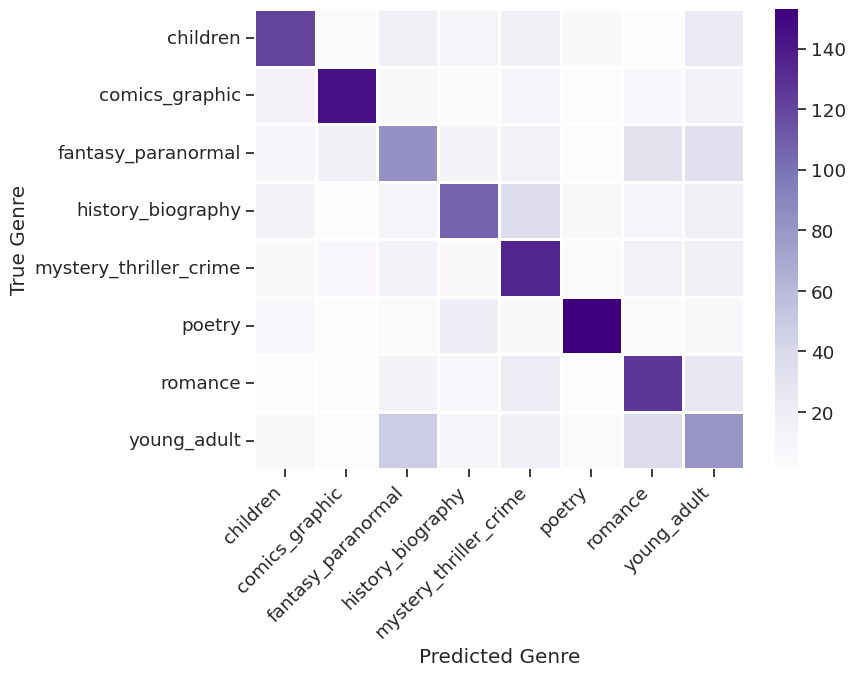

In [48]:
plt.figure(figsize=(9,7))
sns.set(style='ticks', font_scale=1.2)
sns.heatmap(df_wide, linewidths=1, cmap='Purples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Looks good! We can see that overall, our model is assigning the correct labels for each genre.

Now, let's remove the diagonal from the plot to highlight the misclassifications.

In [49]:
genre_classifications_dict = defaultdict(int)
for _true_label, _predicted_label in zip(test_labels, predicted_labels):
  if _true_label != _predicted_label: # Remove the diagonal to highlight misclassifications
    genre_classifications_dict[(_true_label, _predicted_label)] += 1

dicts_to_plot = []
for (_true_genre, _predicted_genre), _count in genre_classifications_dict.items():
  dicts_to_plot.append({'True Genre': _true_genre,
                        'Predicted Genre': _predicted_genre,
                        'Number of Classifications': _count})

df_to_plot = pd.DataFrame(dicts_to_plot)
df_wide = df_to_plot.pivot_table(index='True Genre',
                                 columns='Predicted Genre',
                                 values='Number of Classifications')

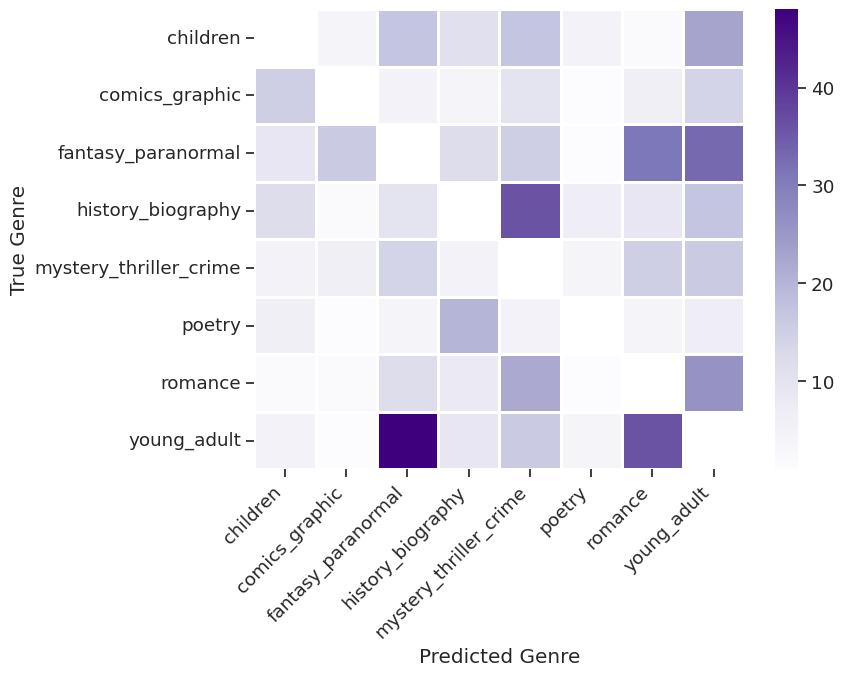

In [50]:
plt.figure(figsize=(9,7))
sns.set(style='ticks', font_scale=1.2)
sns.heatmap(df_wide, linewidths=1, cmap='Purples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

There's much more you can do with your own dataset and labels! Classification can be used to apply a small set of labels across a big dataset; to explore misclassifications to better understand users; and much more! We hope you'll use this tutorial in all kinds of creative ways.

## Task 5: Push Trained Model to Hugging Face Hub

After fine-tuning, push the model and tokenizer to your public Hugging Face profile so it can be loaded by anyone.

In [51]:
from huggingface_hub import login
import os

# Task 5 — Authenticate with Hugging Face (set HF_TOKEN env var or paste token)
# Never hardcode tokens in notebooks. Set the env var before running:
#   export HF_TOKEN="hf_..."
HF_TOKEN = os.environ.get('HF_TOKEN')
HF_REPO_ID = 'kamalchaurasia-iitj/goodreads-reviews-genres'

if HF_TOKEN:
    login(token=HF_TOKEN)
else:
    login()  # prompts interactively

# Push model and tokenizer to your Hugging Face profile
# HF_REPO_ID = 'your-username/distilbert-goodreads-genres'
model.push_to_hub(HF_REPO_ID)
tokenizer.push_to_hub(HF_REPO_ID)
print(f'Model pushed to: https://huggingface.co/{HF_REPO_ID}')

# Record the HF model link in the W&B eval run summary
wandb.run.summary['huggingface_model'] = f'https://huggingface.co/{HF_REPO_ID}'

wandb.finish()

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


README.md: 0.00B [00:00, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
wandb: updating run metadata


Model pushed to: https://huggingface.co/kamalchaurasia-iitj/goodreads-reviews-genres


wandb: 
wandb: Run history:
wandb:           eval/accuracy ▁▅█▅
wandb:                 eval/f1 ▁▆█▆
wandb:               eval/loss █▁▄▁
wandb:            eval/runtime ▁▁█▅
wandb: eval/samples_per_second ██▁▄
wandb:   eval/steps_per_second ██▁▄
wandb:          final/accuracy ▁
wandb:                final/f1 ▁
wandb:              final/loss ▁
wandb:           test/accuracy ▁
wandb:                     +10 ...
wandb: 
wandb: Run summary:
wandb:           eval/accuracy 0.595
wandb:                 eval/f1 0.5989
wandb:               eval/loss 2.3526
wandb:            eval/runtime 27.2317
wandb: eval/samples_per_second 58.755
wandb:   eval/steps_per_second 1.836
wandb:          final/accuracy 0.595
wandb:                final/f1 0.5989
wandb:              final/loss 2.3526
wandb:       huggingface_model https://huggingface....
wandb:                     +16 ...
wandb: 
wandb: 🚀 View run roberta-base-run-20260520_185520 at: https://wandb.ai/kamalchaurasia-iit-jodhpur/MLOps-Goodreads-Reviews/

In [52]:
from huggingface_hub import ModelCard

# ── Build model card content ──────────────────────────────────────────────────
genres = list(id2label.values())
genre_list = "\n".join(f"- `{g}`" for g in genres)

# Pull key metrics from eval_results (populated by trainer.evaluate())
acc  = eval_results.get("eval_accuracy", eval_results.get("accuracy", "N/A"))
f1   = eval_results.get("eval_f1",       eval_results.get("f1", "N/A"))
loss = eval_results.get("eval_loss",     eval_results.get("loss", "N/A"))

if isinstance(acc,  float): acc  = f"{acc:.4f}"
if isinstance(f1,   float): f1   = f"{f1:.4f}"
if isinstance(loss, float): loss = f"{loss:.4f}"

card_content = f"""---
language: en
license: mit
tags:
  - text-classification
  - book-genre
  - goodreads
  - fine-tuned
datasets:
  - goodreads
metrics:
  - accuracy
  - f1
model-index:
  - name: {HF_REPO_ID}
    results:
      - task:
          type: text-classification
          name: Text Classification
        dataset:
          type: custom
          name: UCSD Goodreads Reviews
        metrics:
          - type: accuracy
            value: {acc}
          - type: f1
            value: {f1}
---

# Goodreads Book-Genre Classifier

Fine-tuned [`{model_name}`](https://huggingface.co/{model_name}) for **8-class book-genre classification**
on the [UCSD Goodreads Reviews](https://mengtingwan.github.io/data/goodreads.html) dataset.

## Genres

{genre_list}

## Training details

| Parameter | Value |
|-----------|-------|
| Base model | `{model_name}` |
| Epochs | `{training_args.num_train_epochs}` |
| Learning rate | `{training_args.learning_rate}` |
| Train batch size | `{training_args.per_device_train_batch_size}` |
| Warmup ratio | `{training_args.warmup_ratio}` |
| Weight decay | `{training_args.weight_decay}` |

## Evaluation (test set)

| Metric | Score |
|--------|-------|
| Accuracy | {acc} |
| Macro F1 | {f1} |
| Loss | {loss} |

## Usage

```python
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model="{HF_REPO_ID}",
    tokenizer="{HF_REPO_ID}",
)

result = classifier("I loved the mystery and suspense in this thrilling novel.")
print(result)  # [{{'label': 'mystery_thriller_crime', 'score': 0.98}}]
```

## Citation

```
@misc{{goodreads-genre-classifier,
  author = {{Kamalkumar Chaurasia}},
  title  = {{Goodreads Book-Genre Classifier ({model_name})}},
  year   = {{2026}},
  url    = {{https://huggingface.co/{HF_REPO_ID}}}
}}
```
"""

# ── Push model card to the Hub ────────────────────────────────────────────────
card = ModelCard(card_content)
card.push_to_hub(HF_REPO_ID, token=HF_TOKEN)
print(f"Model card updated: https://huggingface.co/{HF_REPO_ID}")


Model card updated: https://huggingface.co/kamalchaurasia-iitj/goodreads-reviews-genres
